<>:68: SyntaxWarning: invalid escape sequence '\D'
<>:106: SyntaxWarning: invalid escape sequence '\D'
<>:108: SyntaxWarning: invalid escape sequence '\D'
<>:68: SyntaxWarning: invalid escape sequence '\D'
<>:106: SyntaxWarning: invalid escape sequence '\D'
<>:108: SyntaxWarning: invalid escape sequence '\D'
/tmp/ipykernel_8274/2068373777.py:68: SyntaxWarning: invalid escape sequence '\D'
  print(f"4. Optimal Step Size ($\Delta$): {optimal_step_size:.4f}")
/tmp/ipykernel_8274/2068373777.py:106: SyntaxWarning: invalid escape sequence '\D'
  plt.axvline(optimal_step_size, color='black', linestyle='--', label=f'Optimal $\Delta$ = {optimal_step_size:.2f}')
/tmp/ipykernel_8274/2068373777.py:108: SyntaxWarning: invalid escape sequence '\D'
  plt.xlabel('Step Size ($\Delta$)')


       EXPERIMENT 5 CALCULATED VALUES     
1. PCM Mean Squared Error (MSE): 0.0034
2. DPCM Mean Squared Error (MSE): 0.0364
3. Delta Modulation Step Validation: PASSED (All steps are exactly ±Δ)
4. Optimal Step Size ($\Delta$): 0.1612
5. Minimum MSE for Delta Modulation: 0.0088


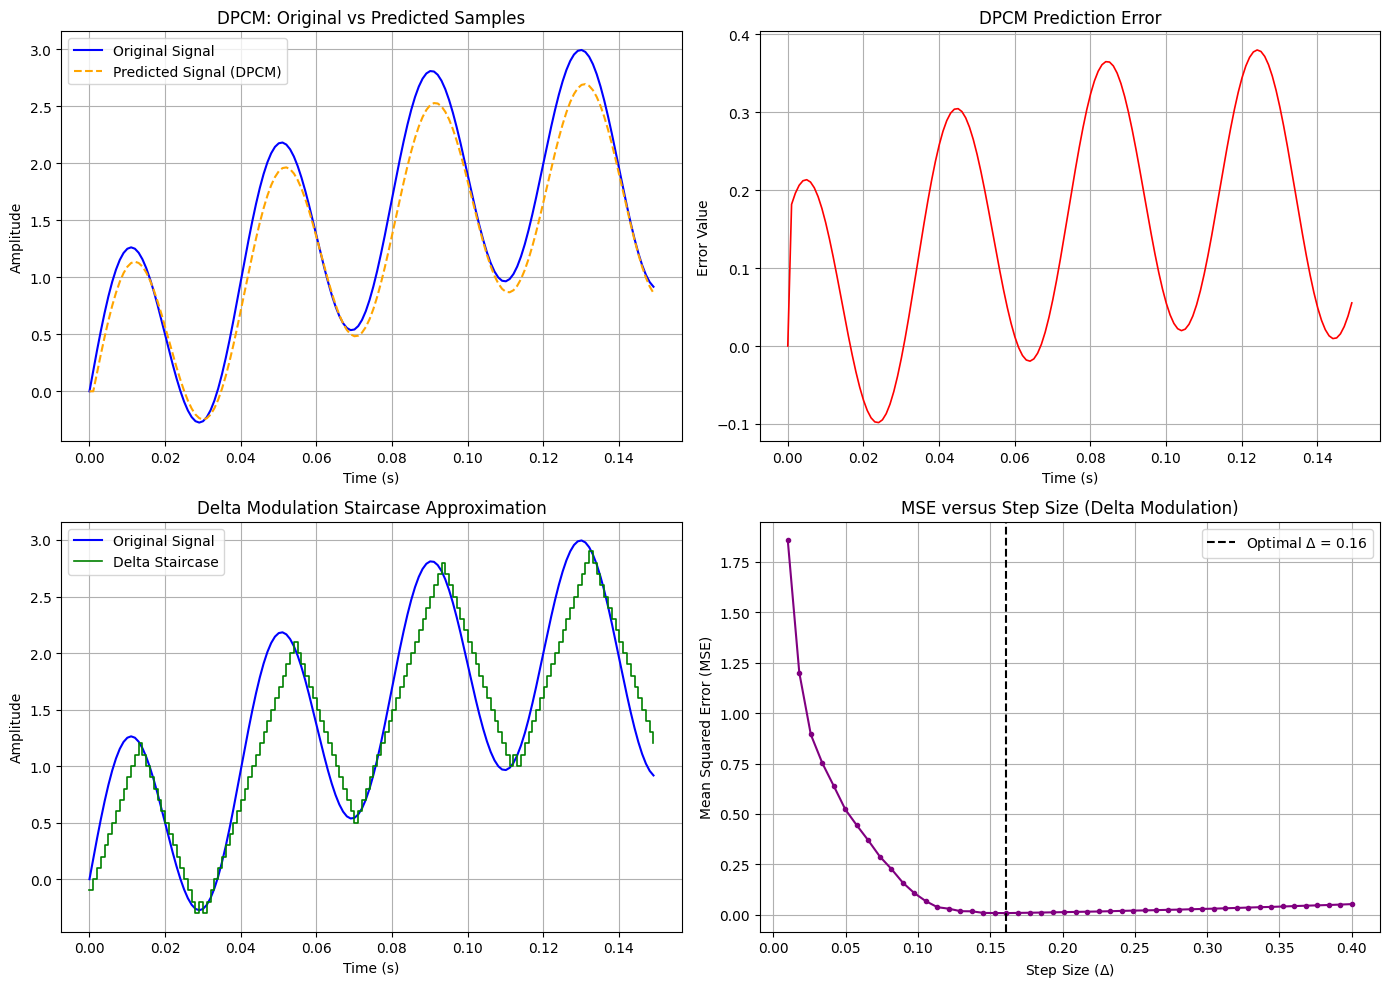

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Input Signal Generation (Slow and rapidly varying combined signal)
fs = 1000  # Sampling frequency
t = np.linspace(0, 1, fs)
input_signal = 2 * np.sin(2 * np.pi * 2 * t) + 1 * np.sin(2 * np.pi * 25 * t)

# --- TASK A & B: PCM vs DPCM Error Calculation ---
# PCM Quantization Error
pcm_quantized = np.round(input_signal / 0.2) * 0.2
pcm_error = input_signal - pcm_quantized
mse_pcm = np.mean(pcm_error**2)

# First-order DPCM Predictor & Error
alpha = 0.9
predicted_signal = np.zeros_like(input_signal)
predicted_signal[1:] = alpha * input_signal[:-1]
dpcm_error = input_signal - predicted_signal
mse_dpcm = np.mean(dpcm_error**2)

# --- TASK C: Delta Modulation & Step Validation ---
delta = 0.1  # Step size
staircase_signal = np.zeros_like(input_signal)
staircase = 0.0
dm_outputs = np.zeros_like(input_signal)

for i in range(len(input_signal)):
    if input_signal[i] > staircase:
        staircase += delta
        dm_outputs[i] = delta
    else:
        staircase -= delta
        dm_outputs[i] = -delta
    staircase_signal[i] = staircase

# Mandatory Validation Check: Inspect whether each delta-modulator output step changes by exactly +delta or -delta
step_diffs = np.abs(np.diff(staircase_signal))
step_changes_valid = np.all(np.isclose(step_diffs, delta) | np.isclose(step_diffs, 0))

# --- TASK D: MSE versus Step Size Analysis (Finding Optimal Value) ---
step_sizes = np.linspace(0.01, 0.4, 50)
mse_list = []

for d in step_sizes:
    sc = 0.0
    sc_sig = np.zeros_like(input_signal)
    for i in range(len(input_signal)):
        if input_signal[i] > sc:
            sc += d
        else:
            sc -= d
        sc_sig[i] = sc
    mse = np.mean((input_signal - sc_sig)**2)
    mse_list.append(mse)

opt_idx = np.argmin(mse_list)
optimal_step_size = step_sizes[opt_idx]
min_mse = mse_list[opt_idx]

# --- PRINTING CALCULATED VALUES FOR REPORT ---
print("==========================================")
print("       EXPERIMENT 5 CALCULATED VALUES     ")
print("==========================================")
print(f"1. PCM Mean Squared Error (MSE): {mse_pcm:.4f}")
print(f"2. DPCM Mean Squared Error (MSE): {mse_dpcm:.4f}")
print(f"3. Delta Modulation Step Validation: {'PASSED (All steps are exactly ±Δ)' if step_changes_valid else 'FAILED'}")
print(f"4. Optimal Step Size ($\Delta$): {optimal_step_size:.4f}")
print(f"5. Minimum MSE for Delta Modulation: {min_mse:.4f}")
print("==========================================")

# --- VISUALIZATIONS ---
plt.figure(figsize=(14, 10))

# 1. Original vs Predicted Samples (DPCM)
plt.subplot(2, 2, 1)
plt.plot(t[:150], input_signal[:150], label='Original Signal', color='blue', linewidth=1.5)
plt.plot(t[:150], predicted_signal[:150], label='Predicted Signal (DPCM)', color='orange', linestyle='--', linewidth=1.5)
plt.title('DPCM: Original vs Predicted Samples')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# 2. Prediction Error
plt.subplot(2, 2, 2)
plt.plot(t[:150], dpcm_error[:150], color='red', linewidth=1.2)
plt.title('DPCM Prediction Error')
plt.xlabel('Time (s)')
plt.ylabel('Error Value')
plt.grid(True)

# 3. Delta Staircase vs Original Signal
plt.subplot(2, 2, 3)
plt.plot(t[:150], input_signal[:150], label='Original Signal', color='blue', linewidth=1.5)
plt.plot(t[:150], staircase_signal[:150], label='Delta Staircase', color='green', drawstyle='steps-post', linewidth=1.2)
plt.title('Delta Modulation Staircase Approximation')
plt.xlabel('Time (s)')
plt.ylabel('Amplitude')
plt.legend()
plt.grid(True)

# 4. MSE versus Step Size
plt.subplot(2, 2, 4)
plt.plot(step_sizes, mse_list, color='purple', marker='o', markersize=3, linewidth=1.5)
plt.axvline(optimal_step_size, color='black', linestyle='--', label=f'Optimal $\Delta$ = {optimal_step_size:.2f}')
plt.title('MSE versus Step Size (Delta Modulation)')
plt.xlabel('Step Size ($\Delta$)')
plt.ylabel('Mean Squared Error (MSE)')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()